# Data Collection

# Création des CSV irradiance par node + graphe


In [ ]:
# Creer les fichiers d'irradiance PVLIB/PVGIS par node + graphe
import re
import pandas as pd
import pvlib
import matplotlib.pyplot as plt
from pathlib import Path

# Annee et source meteo/irradiance.
meteo_year = 2023
timezone = "Europe/Zurich"
raddatabase = "PVGIS-ERA5"

# Plan des panneaux: convention pvlib, 180 deg = sud.
surface_tilt = 60
surface_azimuth = 180

# Fichiers d'entree/sortie. Le notebook est suppose etre lance depuis le dossier marg.
grid_file = Path("87_0_grid.xlsx")
grid_id = "87_0"
node_files = [Path("nodes_valais.csv"), Path("../Jad/nodes_valais.csv")]
node_file = next((candidate for candidate in node_files if candidate.exists()), None)
if node_file is None:
    raise FileNotFoundError("Impossible de trouver nodes_valais.csv. Chemins testes: nodes_valais.csv, ../Jad/nodes_valais.csv")

# Long format: bus, time, datetime, latitude, longitude, irradiance_W_m2.
node_irradiance_file = Path("irradiance_nodes_pvlib_hourly.csv")
# Une ligne par bus: irradiation moyenne et facteur moyen 0..1.
node_mean_file = Path("irradiance_nodes_mean.csv")
# Profil moyen reseau, garde le format historique datetime, irradiance_W_m2.
irradiance_file = Path("irradiance_pvlib_hourly.csv")

force_refresh_irradiance = False


def node_id_from_bus_name(name):
    match = re.search(r"_node_(.+)$", str(name))
    return match.group(1) if match else None


def id_to_str(value):
    try:
        return str(int(float(value)))
    except Exception:
        return str(value)


bus_df = pd.read_excel(grid_file, sheet_name="bus")
first_col = bus_df.columns[0]
if str(first_col).startswith("Unnamed"):
    bus_df = bus_df.rename(columns={first_col: "bus"})
else:
    bus_df = bus_df.reset_index().rename(columns={"index": "bus"})

bus_locations = bus_df[["bus", "name"]].copy()
bus_locations["bus"] = bus_locations["bus"].astype(int)
bus_locations["node_id"] = bus_locations["name"].apply(node_id_from_bus_name)

nodes_geo = pd.read_csv(node_file, encoding="utf-8-sig")
nodes_geo = nodes_geo[nodes_geo["grid_id"].astype(str) == grid_id].copy()
nodes_geo["node_id"] = nodes_geo["osmid"].apply(id_to_str)
nodes_geo["latitude"] = pd.to_numeric(nodes_geo["latitude"], errors="coerce")
nodes_geo["longitude"] = pd.to_numeric(nodes_geo["longitude"], errors="coerce")
nodes_geo = nodes_geo.dropna(subset=["latitude", "longitude"])

bus_locations = bus_locations.merge(
    nodes_geo[["node_id", "latitude", "longitude"]],
    on="node_id",
    how="left",
)
missing_locations = bus_locations[bus_locations[["latitude", "longitude"]].isna().any(axis=1)]
if len(missing_locations):
    display(missing_locations[["bus", "name", "node_id"]].head(20))
    raise ValueError("Certaines coordonnees de bus sont manquantes: verifier le mapping bus -> node dans nodes_valais.csv.")


def cache_is_valid(path, expected_year, expected_buses):
    if not path.exists():
        return False
    cached = pd.read_csv(path, usecols=["bus", "datetime"])
    if len(cached) != 8760 * len(expected_buses):
        return False
    cached_time = pd.to_datetime(cached["datetime"], errors="coerce")
    return (
        not cached_time.isna().any()
        and int(cached_time.iloc[0].year) == expected_year
        and set(cached["bus"].astype(int).unique()) == set(expected_buses)
    )


if force_refresh_irradiance or not cache_is_valid(node_irradiance_file, meteo_year, bus_locations["bus"].tolist()):
    hourly_tables = []
    for row_number, row in bus_locations.sort_values("bus").reset_index(drop=True).iterrows():
        bus = int(row["bus"])
        latitude = float(row["latitude"])
        longitude = float(row["longitude"])
        print(f"PVGIS bus {bus} ({row_number + 1}/{len(bus_locations)}) lat={latitude:.5f}, lon={longitude:.5f}")
        try:
            pv_weather, _ = pvlib.iotools.get_pvgis_hourly(
                latitude=latitude,
                longitude=longitude,
                start=meteo_year,
                end=meteo_year,
                raddatabase=raddatabase,
                components=True,
                surface_tilt=surface_tilt,
                surface_azimuth=surface_azimuth,
                usehorizon=True,
                pvcalculation=False,
                timeout=60,
            )
        except Exception as exc:
            raise RuntimeError(
                f"Impossible de recuperer les donnees PVGIS pour {meteo_year}. "
                "PVGIS-ERA5/PVGIS-SARAH3 ne fournissent souvent les donnees horaires que jusqu'a 2023. "
                "Pour une vraie meteo 2025, il faudra utiliser une autre source meteo, puis garder le meme "
                "format CSV: bus,time,datetime,latitude,longitude,irradiance_W_m2."
            ) from exc

        pv_weather.index = pd.to_datetime(pv_weather.index, utc=True).tz_convert(timezone)
        if (pv_weather.index.minute == 30).all():
            pv_weather.index = pv_weather.index - pd.Timedelta(minutes=30)
        pv_weather = pv_weather[~pv_weather.index.duplicated(keep="first")].sort_index()

        poa_cols = ["poa_direct", "poa_sky_diffuse", "poa_ground_diffuse"]
        irradiance = pv_weather[poa_cols].sum(axis=1).clip(lower=0)
        hourly_tables.append(pd.DataFrame({
            "bus": bus,
            "time": range(len(irradiance)),
            "datetime": irradiance.index.tz_localize(None),
            "latitude": latitude,
            "longitude": longitude,
            "irradiance_W_m2": irradiance.values,
        }))

    node_irradiance = pd.concat(hourly_tables, ignore_index=True)
    node_irradiance.to_csv(node_irradiance_file, index=False)
else:
    node_irradiance = pd.read_csv(node_irradiance_file, parse_dates=["datetime"])

duplicate_count = int(node_irradiance.duplicated(subset=["bus", "time"]).sum())
if duplicate_count:
    print(f"Doublons bus/time detectes dans l'irradiance: {duplicate_count}. Moyenne des doublons appliquee.")
    node_irradiance = (
        node_irradiance
        .groupby(["bus", "time"], as_index=False)
        .agg(
            datetime=("datetime", "first"),
            latitude=("latitude", "first"),
            longitude=("longitude", "first"),
            irradiance_W_m2=("irradiance_W_m2", "mean"),
        )
        .sort_values(["bus", "time"])
    )
    node_irradiance.to_csv(node_irradiance_file, index=False)

if len(node_irradiance) != 8760 * len(bus_locations):
    raise ValueError(f"Irradiance attendue: {8760 * len(bus_locations)} lignes, obtenu: {len(node_irradiance)}")

node_mean = (
    node_irradiance
    .groupby(["bus", "latitude", "longitude"], as_index=False)
    .agg(
        irradiance_mean_W_m2=("irradiance_W_m2", "mean"),
        irradiance_max_W_m2=("irradiance_W_m2", "max"),
    )
)
node_mean["irradiance_mean_norm"] = (
    node_mean["irradiance_mean_W_m2"] / node_mean["irradiance_max_W_m2"].replace(0, pd.NA)
).fillna(0)
node_mean.to_csv(node_mean_file, index=False)

network_irradiance = (
    node_irradiance
    .groupby("datetime", as_index=False)["irradiance_W_m2"]
    .mean()
)
network_irradiance.to_csv(irradiance_file, index=False)

irradiance_pivot = (
    node_irradiance
    .pivot_table(index="datetime", columns="bus", values="irradiance_W_m2", aggfunc="mean")
    .sort_index()
)
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(irradiance_pivot.index, irradiance_pivot.values, color="lightgray", linewidth=0.45, alpha=0.45)
ax.plot(irradiance_pivot.index, irradiance_pivot.mean(axis=1), color="tab:orange", linewidth=1.3, label="Moyenne des nodes")
ax.set_title(f"Irradiance horaire par node - grille {grid_id} - {meteo_year}")
ax.set_xlabel("Temps")
ax.set_ylabel("Irradiance POA (W/m2)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

print(f"Fichier horaire par node: {node_irradiance_file}")
print(f"Fichier moyenne par node: {node_mean_file}")
print(f"Fichier moyen reseau: {irradiance_file}")
display(node_mean.head())


PVGIS bus 0 (1/77) lat=46.32881, lon=8.02405
PVGIS bus 1 (2/77) lat=46.32900, lon=8.02379
PVGIS bus 2 (3/77) lat=46.32929, lon=8.02422
PVGIS bus 3 (4/77) lat=46.32820, lon=8.02319
PVGIS bus 4 (5/77) lat=46.32700, lon=8.02358
PVGIS bus 5 (6/77) lat=46.32751, lon=8.02146
PVGIS bus 6 (7/77) lat=46.32913, lon=8.02375
PVGIS bus 7 (8/77) lat=46.32935, lon=8.02433
PVGIS bus 8 (9/77) lat=46.32661, lon=8.02330
PVGIS bus 9 (10/77) lat=46.32441, lon=8.02275
PVGIS bus 10 (11/77) lat=46.32697, lon=8.02087
PVGIS bus 11 (12/77) lat=46.32402, lon=8.02662
PVGIS bus 12 (13/77) lat=46.32660, lon=8.02785
PVGIS bus 13 (14/77) lat=46.32524, lon=8.02286
PVGIS bus 14 (15/77) lat=46.32946, lon=8.02315
PVGIS bus 15 (16/77) lat=46.32942, lon=8.02442
PVGIS bus 16 (17/77) lat=46.34047, lon=8.01854
PVGIS bus 17 (18/77) lat=46.33596, lon=8.01573
PVGIS bus 18 (19/77) lat=46.33902, lon=8.01245
PVGIS bus 19 (20/77) lat=46.33850, lon=8.00974
PVGIS bus 20 (21/77) lat=46.33799, lon=8.01381
PVGIS bus 21 (22/77) lat=46.3381

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

##########################################
'''DATA'''
##########################################
alpha = 0.3 #TODO Trouver une source qui justifie ce choix 
Tmax= 15 #au dessus : pas de chauffage
Tmin = 0 #en dessous: chauffage maximal
cos_phi = 0.95
delta_Umin = 0.9 #TODO changer avec la bonne valeur selon le type de cable
delta_Umax = 1.10 #TODO changer avec la bonne valeur selon le type de cable
V = 20 #kV

##########################################
# 1. Charger data du fichier 87_grid
file = "87_0_grid.xlsx" # Charger données sur la grid
# 2. Charger le profil de consommation (electrique et de chaleur) totale de la zone --> permet de transformer données aux nodes en séries temporelles
npro = pd.read_excel("2026-05-26-Projet1-profils.xlsx",
                     sheet_name="Profils de charge",
                     skiprows=30,      # sauter jusqu'à la ligne 31
                     nrows=8760)       # lire exactement 8760 lignes

npro.columns = ["extra", "temps", "chaleur_kW", "chauffage_kW", "ecs_kW",
                "chaleur_centre", "froid_kW", "refroid_locaux",
                "refroid_proc", "refroid_centre", "elec_kW",
                "emob_kW", "fonctionnement_kW", "pompe_kW", "temp_C"]
# print(npro.head(3))
npro["chaleur_kW"] = pd.to_numeric(npro["chaleur_kW"], errors="coerce").fillna(0)
npro["fonctionnement_kW"] = pd.to_numeric(npro["fonctionnement_kW"], errors="coerce").fillna(0)
P_chaleur_profile = npro["chaleur_kW"].values / 1000   # MW thermique
P_elec_profile    = npro["fonctionnement_kW"].values / 1000  # MW électrique
f_load_elec    = P_elec_profile / P_elec_profile.max()    # module P_load et Q_load
f_load_chaleur = P_chaleur_profile / P_chaleur_profile.max()  # remplace f_t pour HP

parameters = pd.read_excel(file, sheet_name="parameters")
f =  parameters["f_hz"].values[0] 
omega = 2 * np.pi * f

base = pd.read_excel(file, sheet_name="res_ext_grid") #TODO : CHANGER AVEC NOUVEAU OPF POUR SCENARIO 2 
P_base = base["p_mw"].values
Q_base = base["q_mvar"].values

load = pd.read_excel(file, sheet_name="load")
P_load_agg = - load.groupby("bus")["p_mw"].sum() #tableau avec pour chaque node une valeur de load associée 
Q_load_agg = - load.groupby("bus")["q_mvar"].sum()

bus = pd.read_excel(file, sheet_name="bus")
n_nodes = len(bus)
nodes = range(n_nodes)
P_load = {k: float(P_load_agg.get(k, 0) or 0) for k in nodes} #Remplace Nan par 0
Q_load = {k: float(Q_load_agg.get(k, 0) or 0) for k in nodes} #Remplace Nan par 0
P_load_dt = np.outer(f_load_elec, [P_load[k] for k in nodes])
Q_load_dt = np.outer(f_load_elec, [Q_load[k] for k in nodes])

bus_ref = pd.read_excel(file, sheet_name="res_bus") #TODO : CHANGER AVEC NOUVEAU OPF POUR SCENARIO 2 
P_ref = - bus_ref["p_mw"].values 
Q_ref = - bus_ref["q_mvar"].values

trafo = pd.read_excel(file, sheet_name="trafo")
pcc_bus = int(trafo["lv_bus"].iloc[0])

lines = pd.read_excel(file, sheet_name="line")
line_data = pd.DataFrame({
    "from_bus": lines["from_bus"],
    "to_bus": lines["to_bus"],
    "length": lines["length_km"],
    "r": lines["r_ohm_per_km"] * lines["length_km"],
    "x": lines["x_ohm_per_km"] * lines["length_km"],
    "c": lines["c_nf_per_km"] * lines["length_km"] * 1e-9,
    "I_max": lines["max_i_ka"]
})

#Construire gij, bij, bij(sh)
line_data["g"] = line_data["r"] / (line_data["r"]**2 + line_data["x"]**2)
line_data["b"] = -line_data["x"] / (line_data["r"]**2 + line_data["x"]**2)
line_data["b_sh"] = omega * line_data["c"]
#print(line_data.head()) 

#Construire les matrices Jacobiennes
# Initialisation des matrices
J_Ptheta = np.zeros((n_nodes, n_nodes))
J_QU     = np.zeros((n_nodes, n_nodes))
J_PU     = np.zeros((n_nodes, n_nodes))
# Boucle sur chaque ligne ij
for l in range(len(line_data)):
    i = int(line_data.loc[l, "from_bus"])
    j = int(line_data.loc[l, "to_bus"])

    gij = line_data.loc[l, "g"]
    bij = line_data.loc[l, "b"]
    bsh = line_data.loc[l, "b_sh"]
# 1. MATRICE J_Ptheta
    # diagonale
    J_Ptheta[i, i] -= bij
    J_Ptheta[j, j] -= bij
    # hors diagonale
    J_Ptheta[i, j] += bij
    J_Ptheta[j, i] += bij
# 2. MATRICE J_QU
    # diagonale
    J_QU[i, i] -= (2*bsh + bij)
    J_QU[j, j] -= (2*bsh + bij)
    # hors diagonale
    J_QU[i, j] += bij
    J_QU[j, i] += bij
# 3. MATRICE J_PU
    # diagonale
    J_PU[i, i] += gij
    J_PU[j, j] += gij
    # hors diagonale
    J_PU[i, j] -= gij
    J_PU[j, i] -= gij
# 4. MATRICE J_Qtheta
J_Qtheta = - J_PU
#Calculer S_max 
line_data["S_max"] = np.sqrt(3) * line_data["I_max"] * V

##########################################
# 2. Charger data des PV
# La cellule precedente cree l'irradiance horaire et moyenne par node.
node_irradiance_file = "irradiance_nodes_pvlib_hourly.csv"
node_mean_file = "irradiance_nodes_mean.csv"
expected_irradiance_year = 2023

irr_nodes = pd.read_csv(node_irradiance_file)
irr_mean = pd.read_csv(node_mean_file)
irr_nodes["datetime"] = pd.to_datetime(irr_nodes["datetime"], errors="coerce")
if irr_nodes["datetime"].isna().any() or irr_nodes["datetime"].iloc[0].year != expected_irradiance_year:
    raise ValueError(
        f"Le fichier {node_irradiance_file} ne correspond pas a {expected_irradiance_year}. "
        "Execute d'abord la cellule precedente qui cree les CSV d'irradiance par node."
    )
if len(irr_nodes) != 8760 * n_nodes:
    raise ValueError(f"Le fichier {node_irradiance_file} doit contenir {8760 * n_nodes} lignes, pas {len(irr_nodes)}.")

duplicate_count = int(irr_nodes.duplicated(subset=["bus", "time"]).sum())
if duplicate_count:
    print(f"Doublons bus/time detectes dans {node_irradiance_file}: {duplicate_count}. Moyenne des doublons appliquee.")

irradiance_by_node = (
    irr_nodes
    .pivot_table(index="time", columns="bus", values="irradiance_W_m2", aggfunc="mean")
    .reindex(index=range(8760), columns=list(nodes))
    .fillna(0)
)
G_node = irradiance_by_node.values
G_node_max = np.maximum(G_node.max(axis=0), 1e-9)
G_norm_node_dt = G_node / G_node_max

G_mean_norm_by_bus = (
    irr_mean
    .set_index("bus")["irradiance_mean_norm"]
    .reindex(list(nodes))
    .fillna(0)
)

pv_data = []    # Data PV moyenne par load/node
pv_data_dt = [] # Data PV par load/node par heure de l'annee
for k in range(n_nodes):
    Pk = abs(P_load_agg.get(k, 0))  # load au node k
    Ppv_installed = alpha * Pk      # puissance PV installee au node k
    irradiance_mean_factor = float(G_mean_norm_by_bus.get(k, 0))
    Ppv = Ppv_installed * irradiance_mean_factor
    Qpv = Ppv * np.tan(np.arccos(cos_phi))
    pv_data.append({
        "bus": k,
        "P_pv_installed": Ppv_installed,
        "irradiance_mean_norm": irradiance_mean_factor,
        "P_pv": Ppv,
        "Q_pv": Qpv
    })
    for t in range(8760):
        irradiance_factor_t = float(G_norm_node_dt[t, k])
        Ppv_t = Ppv_installed * irradiance_factor_t
        Qpv_t = Ppv_t * np.tan(np.arccos(cos_phi))
        pv_data_dt.append({
            "bus": k,
            "time": t,
            "irradiance_norm": irradiance_factor_t,
            "P_pv": Ppv_t,
            "Q_pv": Qpv_t
        })
pv_df = pd.DataFrame(pv_data)
P_pv_max = pv_df.set_index("bus")["P_pv"]
Q_pv_max = pv_df.set_index("bus")["Q_pv"]
pv_df.to_csv("pv_data.csv", index=False)
pv_df_dt = pd.DataFrame(pv_data_dt)
P_pv_max_dt = pv_df_dt.set_index(["time", "bus"])["P_pv"]
Q_pv_max_dt = pv_df_dt.set_index(["time", "bus"])["Q_pv"]
pv_df_dt.to_csv("pv_data_dt.csv", index=False)

##########################################
# 3. Charger data des HP
COP = 3.9         # heat pump (nPro) #TODO changer quand zone bien délimitée
P_hp_total = - 26072 / 1000 # MW thermique (nPro) #TODO changer quand zone bien délimitée

# temp = pd.read_csv("temperature_hourly.csv") #TODO changer avec bon fichier
# T = temp["temperature_C"].values
# f_t = np.clip((Tmax - T) / (Tmax - Tmin), 0, 1) # Fonction chauffage qui indique consommation de l'HP en fonction de la temperature exterieure 

P_hp_total_elec = P_hp_total / COP #puissance electrique totale 
Pk_total = P_load_agg.sum() # Total load

hp_data = []
hp_data_dt = []
for k in range(n_nodes):
    Pk = P_load_agg.get(k, 0)
    P_hp = P_hp_total_elec * (Pk / Pk_total)
    hp_data.append({
        "bus": k,
        "P_hp": P_hp
    })
    for t in range(len(f_load_chaleur)):
        P_hp_dt = P_hp * f_load_chaleur[t]
        hp_data_dt.append({
            "bus": k,
            "time": t,
            "P_hp": P_hp_dt
        })
hp_df = pd.DataFrame(hp_data)
P_hp_max = hp_df.set_index("bus")["P_hp"] #Structure les données pour Gurobi
hp_df.to_csv("hp_data.csv", index=False)
hp_df_dt = pd.DataFrame(hp_data_dt)
P_hp_max_dt = hp_df_dt.set_index(["time", "bus"])["P_hp"]
hp_df_dt.to_csv("hp_data_dt.csv", index=False)

# print("Bilan de faisabilité par nœud :")
# for k in nodes:
#     # Convention : PV > 0 (génération), HP < 0 (conso), load < 0 (conso)
#     pk_min = 0 + P_hp_max.get(k, 0) + P_load.get(k, 0)          # P_pv = 0, HP au max
#     pk_max = P_pv_max.get(k, 0) + 0 + P_load.get(k, 0)           # P_pv au max, HP = 0
#     pr = P_ref[k]
#     print(f"Nœud {k:3d} | P_ref={pr:+.4f} | Pk ∈ [{pk_min:+.4f}, {pk_max:+.4f}] {'❌' if pr < pk_min or pr > pk_max else '✅'}")


# Probleme d'optimization qui crée le  FFOR

In [56]:
import gurobipy as gp
from gurobipy import GRB
import numpy as np

# =========================
# MODELE
# =========================

model = gp.Model("FFOR_static")

# =========================
# VARIABLES
# =========================
Pk = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Pk")
Qk = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Qk")
theta = model.addVars(n_nodes, lb=-GRB.INFINITY, name="theta")
delta_U     = model.addVars(n_nodes, lb=-GRB.INFINITY, name="U")
P_pv = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Ppv")
Q_pv = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Qpv")
P_hp = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Php")

# =========================
# CONTRAINTES FFOR
# =========================

# # Nodal Power Balance
# for k in nodes:
#     model.addConstr(
#         Pk[k] == P_pv[k] + P_hp[k] + P_load.get(k, 0),
#         name=f"Nodal_P_balance_{k}"
#     )
#     model.addConstr(
#         Qk[k] == Q_pv[k] + Q_load.get(k, 0),
#         name=f"Nodal_Q_balance_{k}"
#     )
# Nodal Power Balance — sauf le nœud PCC
for k in nodes:
    if k == pcc_bus:
        continue  # ← le PCC est libre, pas de bilan nodal
    model.addConstr(
        Pk[k] == P_pv[k] + P_hp[k] + P_load.get(k, 0),
        name=f"Nodal_P_balance_{k}"
    )
    model.addConstr(
        Qk[k] == Q_pv[k] + Q_load.get(k, 0),
        name=f"Nodal_Q_balance_{k}"
    )
#Linearized Power Flow
for k in nodes:
    model.addConstr(
        Pk[k] == P_ref[k]
        +
        gp.quicksum(J_Ptheta[k, j] * theta[j] for j in nodes)
        +
        gp.quicksum(J_PU[k, j] * delta_U[j] for j in nodes),
        name=f"Power_flow_P{k}"
    )
    model.addConstr(
        Qk[k] == Q_ref[k]
        +
        gp.quicksum(J_Qtheta[k, j] * theta[j] for j in nodes)
        +
        gp.quicksum(J_QU[k, j] * delta_U[j] for j in nodes),
        name=f"Power_flow_Q{k}"
    )

#PV constraint 
for k in nodes:
    model.addConstr(P_pv[k] <= P_pv_max.get(k, 0),
        name=f"PV_Pmax_pos_{k}"
    )
    model.addConstr(0 <= P_pv[k],
        name=f"PV_Pmax_neg_{k}"
    )
    model.addConstr(Q_pv[k] <= Q_pv_max[k],
        name=f"PV_Qmax_pos_{k}"
    )
    model.addConstr(Q_pv[k] >= -Q_pv_max[k],
        name=f"PV_Qmax_neg_{k}"
    )

#HP constraint 
for k in nodes:
    model.addConstr(P_hp[k] >= P_hp_max.get(k, 0),
        name=f"HP_Pmax_pos_{k}"
    )
    model.addConstr(0 >= P_hp[k],
        name=f"HP_Pmax_neg_{k}"
    )

#Line flow constraint
for idx, row in line_data.iterrows():
    i = int(row["from_bus"])
    j = int(row["to_bus"])
    b = row["b"]
    Smax = row["S_max"]
    Pij = b * (theta[i] - theta[j]) #TODO verifier cette equation
    Qij = b * (delta_U[i] - delta_U[j]) #TODO verifier cette equation

    model.addQConstr(
        Pij * Pij + Qij * Qij <= Smax * Smax,
        name=f"line_flow_{i}_{j}"
    )

#Voltage Constraint
for k in nodes:
    model.addConstr(
        V + delta_U[k] >= delta_Umin*V,
        name=f"Umin_{k}"
    )
    model.addConstr(
        V + delta_U[k] <= delta_Umax*V,
        name=f"Umax_{k}"
    )

#Slack Constraint
model.addConstr(
    theta[pcc_bus] == 0,
    name="Slack_theta"
)
model.addConstr(
    delta_U[pcc_bus] == 0,
    name="Slack_voltage"
)

# =========================
# OBJECTIF
# =========================
a = 0.5
b = 0.5

model.setObjective(
    a * (Pk[pcc_bus] - float(P_base[0]))
    + b * (Qk[pcc_bus] - float(Q_base[0])),
    GRB.MINIMIZE
)

# =========================
# SOLVE
# =========================
model.Params.DualReductions = 0  # désactive les réductions duales
model.optimize()
if model.status == GRB.INFEASIBLE:
    print("Calcul IIS...")
    model.computeIIS()
    model.write("model.ilp")
    
    print("\n--- Contraintes infaisables ---")
    for c in model.getConstrs():
        if c.IISConstr:
            print(f"  {c.ConstrName}")
    
    print("\n--- Bornes infaisables ---")
    for v in model.getVars():
        if v.IISLB:
            print(f"  {v.VarName} lb={v.lb} trop haute")
        if v.IISUB:
            print(f"  {v.VarName} ub={v.ub} trop basse")

# =========================
# AFFICHAGE RESULTATS
# =========================

if model.status == GRB.OPTIMAL:
    print("\n✅ OPTIMAL SOLUTION FOUND\n")

    print("----- PCC -----")
    print(f"P_pcc = {Pk[pcc_bus].X:.4f}")
    print(f"Q_pcc = {Qk[pcc_bus].X:.4f}")

    print("\n----- Pk -----")
    for k in nodes:
        print(f"Pk[{k}] = {Pk[k].X:.4f}")

    print("\n----- Qk -----")
    for k in nodes:
        print(f"Qk[{k}] = {Qk[k].X:.4f}")

    print("\n----- Theta -----")
    for k in nodes:
        print(f"theta[{k}] = {theta[k].X:.6f}")

    print("\n----- Voltage (delta_U) -----")
    for k in nodes:
        print(f"delta_U[{k}] = {delta_U[k].X:.6f}")

    print("\n----- PV -----")
    for k in nodes:
        print(f"P_pv[{k}] = {P_pv[k].X:.4f}, Q_pv[{k}] = {Q_pv[k].X:.4f}")

    print("\n----- HP -----")
    for k in nodes:
        print(f"P_hp[{k}] = {P_hp[k].X:.4f}")

else:
    print("\n❌ Optimization did not find optimal solution")
    print("Status code:", model.status)

# model.computeIIS()

# print("\n--- Contraintes infaisables ---")
# for c in model.getConstrs():
#     if c.IISConstr:
#         print(f"  {c.ConstrName}  RHS={c.RHS:.4f}")

# for v in model.getVars():
#     if v.IISLB:
#         print(f"  VAR {v.VarName} lb={v.lb} trop haute")
#     if v.IISUB:
#         print(f"  VAR {v.VarName} ub={v.ub} trop basse")


Set parameter DualReductions to value 0
Gurobi Optimizer version 13.0.2 build v13.0.2rc1 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i7-1065G7 CPU @ 1.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
DualReductions  0

Optimize a model with 924 rows, 539 columns and 2056 nonzeros (Min)
Model fingerprint: 0x929ad685
Model has 2 linear objective coefficients and an objective constant of -6.3470047460994108e+00
Model has 75 quadratic constraints
Coefficient statistics:
  Matrix range     [4e-01, 1e+03]
  QMatrix range    [2e-01, 1e+06]
  Objective range  [5e-01, 5e-01]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e-03, 9e+00]
  QRHS range       [5e+01, 5e+02]

Presolve removed 774 rows and 264 columns
Presolve time: 0.02s
Presolved: 296 rows, 496 columns, 1445 nonzeros
Presolved model has 75 second-order cone constraints
Ordering time: 0.00s

Barrier statistics:


# FFOR

Set parameter Username
Set parameter LicenseID to value 2806507
Academic license - for non-commercial use only - expires 2027-04-13
  1/72 | phi=0.0° | P=6.278, Q=3.797
  2/72 | phi=5.0° | P=6.278, Q=2.882
  3/72 | phi=10.0° | P=6.278, Q=2.882
  4/72 | phi=15.0° | P=6.278, Q=2.882
  5/72 | phi=20.0° | P=6.278, Q=2.882
  6/72 | phi=25.0° | P=6.278, Q=2.882
  7/72 | phi=30.0° | P=6.278, Q=2.882
  8/72 | phi=35.0° | P=6.278, Q=2.882
  9/72 | phi=40.0° | P=6.278, Q=2.882
  10/72 | phi=45.0° | P=6.278, Q=2.882
  11/72 | phi=50.0° | P=6.278, Q=2.882
  12/72 | phi=55.0° | P=6.278, Q=2.882
  13/72 | phi=60.0° | P=6.278, Q=2.882
  14/72 | phi=65.0° | P=6.278, Q=2.882
  15/72 | phi=70.0° | P=6.278, Q=2.882
  16/72 | phi=75.0° | P=6.278, Q=2.882
  17/72 | phi=80.0° | P=6.278, Q=2.882
  18/72 | phi=85.0° | P=6.278, Q=2.882
  19/72 | phi=90.0° | P=6.326, Q=2.882
  20/72 | phi=95.0° | P=8.933, Q=2.887
  21/72 | phi=100.0° | P=8.933, Q=2.887
  22/72 | phi=105.0° | P=8.933, Q=2.887
  23/72 | phi=110.0

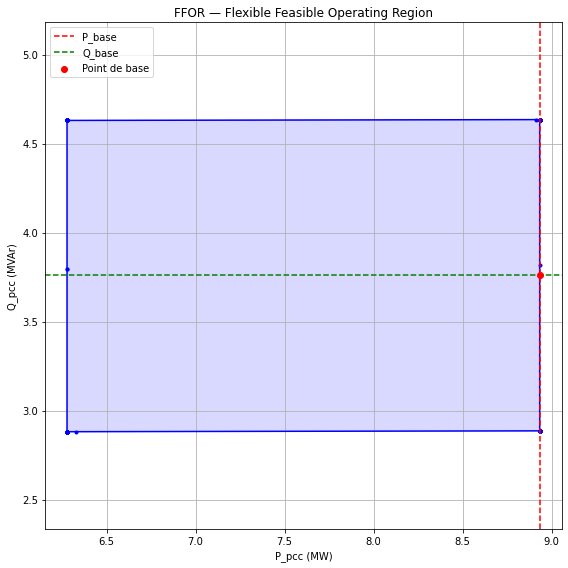

S_max min = 7.27 MVA
S_max max = 22.34 MVA
Plage P_pcc : [6.28, 8.93] MW
Plage Q_pcc : [2.88, 4.64] MVAr


In [12]:
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

def solve_ffor(a, b):
    """Résout le modèle FFOR pour une direction (a, b) donnée."""
    model = gp.Model("FFOR_static")
    model.Params.OutputFlag = 0  # silence Gurobi

    # --- Variables ---
    Pk      = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Pk")
    Qk      = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Qk")
    theta   = model.addVars(n_nodes, lb=-GRB.INFINITY, name="theta")
    delta_U = model.addVars(n_nodes, lb=-GRB.INFINITY, name="U")
    P_pv    = model.addVars(n_nodes, lb=0,             name="Ppv")
    Q_pv    = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Qpv")
    P_hp    = model.addVars(n_nodes, ub=0,             name="Php")

    # --- Contraintes ---
    for k in nodes:
        if k == pcc_bus:
            continue
        model.addConstr(Pk[k] == P_pv[k] + P_hp[k] + P_load.get(k, 0))
        model.addConstr(Qk[k] == Q_pv[k] + Q_load.get(k, 0))

    for k in nodes:
        model.addConstr(Pk[k] == P_ref[k] + gp.quicksum(J_Ptheta[k,j]*theta[j] + J_PU[k,j]*delta_U[j] for j in nodes))
        model.addConstr(Qk[k] == Q_ref[k] + gp.quicksum(J_Qtheta[k,j]*theta[j] + J_QU[k,j]*delta_U[j] for j in nodes))

    for k in nodes:
        model.addConstr(P_pv[k] <= P_pv_max.get(k, 0))
        model.addConstr(Q_pv[k] <=  Q_pv_max.get(k, 0))
        model.addConstr(Q_pv[k] >= -Q_pv_max.get(k, 0))
        model.addConstr(P_hp[k] >= P_hp_max.get(k, 0))

    for idx, row in line_data.iterrows():
        i, j = int(row["from_bus"]), int(row["to_bus"])
        Pij = - row["b"] * (theta[i] - theta[j])
        Qij = - row["b"] * (delta_U[i] - delta_U[j])
        model.addQConstr(Pij*Pij + Qij*Qij <= row["S_max"]**2)

    for k in nodes:
        model.addConstr(V + delta_U[k] >= delta_Umin * V)
        model.addConstr(V + delta_U[k] <= delta_Umax * V)

    model.addConstr(theta[pcc_bus] == 0)
    model.addConstr(delta_U[pcc_bus] == 0)

    for k in nodes:
        S_inv = P_pv_max.get(k, 0) / cos_phi  # capacité apparente de l'onduleur
        model.addQConstr(
            P_pv[k] * P_pv[k] + Q_pv[k] * Q_pv[k] <= S_inv * S_inv,
            name=f"PV_Smax_{k}"
        )

    # --- Objectif directionnel ---
    model.setObjective(
        a * Pk[pcc_bus] + b * Qk[pcc_bus],
        GRB.MINIMIZE
    )

    model.optimize()

    if model.status == GRB.OPTIMAL:
        return Pk[pcc_bus].X, Qk[pcc_bus].X
    else:
        return None, None


# --- Balayage sur 360° ---
n_angles = 72  # résolution : tous les 5°
angles = np.linspace(0, 2*np.pi, n_angles, endpoint=False)

P_points = []
Q_points = []

for i, phi in enumerate(angles):
    a = np.cos(phi)
    b = np.sin(phi)
    p, q = solve_ffor(a, b)
    if p is not None:
        P_points.append(p)
        Q_points.append(q)
    print(f"  {i+1}/{n_angles} | phi={np.degrees(phi):.1f}° | P={p:.3f}, Q={q:.3f}" if p else f"  {i+1}/{n_angles} | ❌ infaisable")

# Fermer le polygone
P_points.append(P_points[0])
Q_points.append(Q_points[0])

# --- Plot ---
plt.figure(figsize=(8, 8))
plt.plot(P_points, Q_points, 'b-o', markersize=3, linewidth=1.5)
plt.fill(P_points, Q_points, alpha=0.15, color='blue')
plt.axvline(float(P_base[0]), color='r', linestyle='--', label='P_base')
plt.axhline(float(Q_base[0]), color='g', linestyle='--', label='Q_base')
plt.scatter([float(P_base[0])], [float(Q_base[0])], color='red', zorder=5, label='Point de base')
plt.xlabel("P_pcc (MW)")
plt.ylabel("Q_pcc (MVAr)")
plt.title("FFOR — Flexible Feasible Operating Region")
plt.legend()
plt.grid(True)
plt.axis('equal')
plt.tight_layout()
plt.savefig("FFOR.png", dpi=150)
plt.show()

print(f"S_max min = {line_data['S_max'].min():.2f} MVA")
print(f"S_max max = {line_data['S_max'].max():.2f} MVA")
print(f"Plage P_pcc : [{min(P_points):.2f}, {max(P_points):.2f}] MW")
print(f"Plage Q_pcc : [{min(Q_points):.2f}, {max(Q_points):.2f}] MVAr")

# Dimention temporelle 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB

# --- Paramètres du balayage ---
n_angles = 36
n_hours  = 8760        
angles   = np.linspace(0, 2*np.pi, n_angles, endpoint=False)

def solve_ffor_t(a, b, t):
    """Résout le modèle FFOR pour une direction (a, b) et une heure t."""
    model = gp.Model("FFOR_t")

    # Données à l'heure t
    P_load_t   = {k: P_load_dt[t, k] for k in nodes}
    Q_load_t   = {k: Q_load_dt[t, k] for k in nodes}
    P_pv_max_t = {k: P_pv_max_dt[t, k] for k in nodes}
    Q_pv_max_t = {k: Q_pv_max_dt[t, k] for k in nodes}
    P_hp_max_t = {k: P_hp_max_dt[t, k] for k in nodes}  

    # --- Variables ---
    Pk      = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Pk")
    Qk      = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Qk")
    theta   = model.addVars(n_nodes, lb=-GRB.INFINITY, name="theta")
    delta_U = model.addVars(n_nodes, lb=-GRB.INFINITY, name="U")
    P_pv    = model.addVars(n_nodes, lb=0,             name="Ppv")
    Q_pv    = model.addVars(n_nodes, lb=-GRB.INFINITY, name="Qpv")
    P_hp    = model.addVars(n_nodes, ub=0,             name="Php")

    # --- Contraintes ---
    for k in nodes:
        if k == pcc_bus:
            continue
        if np.isnan(P_load_t[k]):
            print("NaN P_load_t :", t, k)
        if np.isnan(Q_load_t[k]):
            print("NaN Q_load_t :", t, k)
        model.addConstr(Pk[k] == P_pv[k] + P_hp[k] + P_load_t[k])
        model.addConstr(Qk[k] == Q_pv[k] + Q_load_t[k])

    for k in nodes:
        model.addConstr(Pk[k] == P_ref[k] + gp.quicksum(J_Ptheta[k,j]*theta[j] + J_PU[k,j]*delta_U[j] for j in nodes))
        model.addConstr(Qk[k] == Q_ref[k] + gp.quicksum(J_Qtheta[k,j]*theta[j] + J_QU[k,j]*delta_U[j] for j in nodes))

    for k in nodes:
        model.addConstr(P_pv[k] <= P_pv_max_t[k])
        model.addConstr(Q_pv[k] <=  Q_pv_max_t[k])
        model.addConstr(Q_pv[k] >= -Q_pv_max_t[k])
        model.addConstr(P_hp[k] >= P_hp_max_t[k])

    for idx, row in line_data.iterrows():
        i, j = int(row["from_bus"]), int(row["to_bus"])
        Pij = -row["b"] * (theta[i] - theta[j])
        Qij = -row["b"] * (delta_U[i] - delta_U[j])
        model.addQConstr(Pij*Pij + Qij*Qij <= row["S_max"]**2)

    for k in nodes:
        model.addConstr(V + delta_U[k] >= delta_Umin * V)
        model.addConstr(V + delta_U[k] <= delta_Umax * V)

    model.addConstr(theta[pcc_bus] == 0)
    model.addConstr(delta_U[pcc_bus] == 0)

    for k in nodes:
        S_inv = P_pv_max_t[k] / cos_phi
        model.addQConstr(
            P_pv[k] * P_pv[k] + Q_pv[k] * Q_pv[k] <= S_inv * S_inv,
            name=f"PV_Smax_{k}"
        )

    # --- Objectif directionnel ---
    model.setObjective(
        a * Pk[pcc_bus] + b * Qk[pcc_bus],
        GRB.MINIMIZE
    )

    model.optimize()

    if model.status == GRB.OPTIMAL:
        return Pk[pcc_bus].X, Qk[pcc_bus].X
    else:
        return None, None


# --- Paramètres du balayage ---
n_angles = 36          # tous les 10° — bon compromis vitesse/précision pour 8760h
n_hours  = 8760        # nombre d'heures à simuler
angles   = np.linspace(0, 2*np.pi, n_angles, endpoint=False)

# --- Stocker les résultats ---
ffor_results = {}  # {t: {"P": [...], "Q": [...]}}

for t in range(n_hours):
    if t % 100 == 0:
        print(f"Heure {t}/{n_hours}...")

    P_pts, Q_pts = [], []
    for phi in angles:
        p, q = solve_ffor_t(np.cos(phi), np.sin(phi), t)
        if p is not None:
            P_pts.append(p)
            Q_pts.append(q)

    ffor_results[t] = {"P": P_pts, "Q": Q_pts}

print("✅ Calcul terminé !")

# --- Plot : enveloppe annuelle (superposition de tous les FFOR) ---
fig, ax = plt.subplots(figsize=(9, 9))

for t in range(n_hours):
    pts = ffor_results[t]
    if len(pts["P"]) > 2:
        P_closed = pts["P"] + [pts["P"][0]]
        Q_closed = pts["Q"] + [pts["Q"][0]]
        ax.fill(P_closed, Q_closed, alpha=0.01, color='blue')

# Quelques heures représentatives en évidence
heures_rep = {
    "Hiver 8h"  : 7,
    "Hiver 14h" : 13,
    "Été 8h"    : 4391,
    "Été 14h"   : 4397,
}
colors = ['red', 'orange', 'green', 'purple']
for (label, t), color in zip(heures_rep.items(), colors):
    pts = ffor_results[t]
    if len(pts["P"]) > 2:
        P_closed = pts["P"] + [pts["P"][0]]
        Q_closed = pts["Q"] + [pts["Q"][0]]
        ax.plot(P_closed, Q_closed, color=color, linewidth=1.5, label=label)

ax.axvline(float(P_base[0]), color='r', linestyle='--', label='P_base')
ax.axhline(float(Q_base[0]), color='g', linestyle='--', label='Q_base')
ax.scatter([float(P_base[0])], [float(Q_base[0])], color='red', zorder=5, label='Point de base')
ax.set_xlabel("P_pcc (MW)")
ax.set_ylabel("Q_pcc (MVAr)")
ax.set_title("FFOR annuel — enveloppe des 8760 heures")
ax.legend()
ax.grid(True)
ax.axis('equal')
plt.tight_layout()
plt.savefig("FFOR_annuel.png", dpi=150)
plt.show()


Heure 0/8760...
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (win64 - Windows 11+.0 (26200.2))

CPU model: Intel(R) Core(TM) i7-1065G7 CPU @ 1.30GHz, instruction set [SSE2|AVX|AVX2|AVX512]
Thread count: 4 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 770 rows, 539 columns and 1902 nonzeros (Min)
Model fingerprint: 0x1095f0ea
Model has 1 linear objective coefficients
Model has 152 quadratic constraints
Coefficient statistics:
  Matrix range     [4e-01, 1e+03]
  QMatrix range    [2e-01, 1e+06]
  Objective range  [1e+00, 1e+00]
  Bounds range     [0e+00, 0e+00]
  RHS range        [6e-03, 9e+00]
  QRHS range       [5e+01, 5e+02]

Presolve removed 620 rows and 389 columns
Presolve time: 0.02s
Presolved: 296 rows, 371 columns, 1322 nonzeros
Presolved model has 75 second-order cone constraints
Ordering time: 0.01s

Barrier statistics:
 Free vars  : 73
 AA' NZ     : 2.326e+03
 Factor NZ  : 4.179e+03
 Factor Ops : 6.729e+04 (less than 1 second per iterat

# Carte grille 87_0 avec BelalpSolar


In [ ]:
import re
import math
from pathlib import Path

import pandas as pd
import pandapower as pp
import plotly.graph_objects as go
import plotly.io as pio
from plotly.colors import sample_colorscale

pio.renderers.default = "vscode"

grid_file = Path("87_0_grid.xlsx")
grid_id = "87_0"
node_files = [Path("nodes_valais.csv"), Path("../Jad/nodes_valais.csv")]
nodes_file = next((candidate for candidate in node_files if candidate.exists()), None)
if nodes_file is None:
    raise FileNotFoundError("Impossible de trouver nodes_valais.csv. Chemins testes: nodes_valais.csv, ../Jad/nodes_valais.csv")

belalp_name = "BelalpSolar"
belalp_latitude = 46.39776
belalp_longitude = 7.97738
belalp_p_mw = 5.7

net_map = pp.from_excel(grid_file)
pp.runpp(net_map)
nodes_geo = pd.read_csv(nodes_file, encoding="utf-8-sig")


def id_to_str(value):
    try:
        return str(int(float(value)))
    except Exception:
        return str(value)


def node_id_from_bus_name(name):
    match = re.search(r"_node_(.+)$", str(name))
    return match.group(1) if match else None


def haversine_km(lon1, lat1, lon2, lat2):
    radius_km = 6371.0
    lon1, lat1, lon2, lat2 = map(math.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return 2 * radius_km * math.asin(math.sqrt(a))


nodes_grid = nodes_geo[nodes_geo["grid_id"].astype(str) == grid_id].dropna(subset=["osmid", "longitude", "latitude"]).copy()
nodes_grid["node_id"] = nodes_grid["osmid"].apply(id_to_str)
nodes_grid["longitude"] = pd.to_numeric(nodes_grid["longitude"], errors="coerce")
nodes_grid["latitude"] = pd.to_numeric(nodes_grid["latitude"], errors="coerce")
node_lookup = nodes_grid.drop_duplicates("node_id").set_index("node_id")[["longitude", "latitude"]]

bus_plot = net_map.bus.copy()
bus_plot["bus"] = bus_plot.index.astype(int)
bus_plot["node_id"] = bus_plot["name"].apply(node_id_from_bus_name)
bus_plot = bus_plot.join(node_lookup, on="node_id")
bus_plot = bus_plot.dropna(subset=["longitude", "latitude"]).set_index("bus")

if bus_plot.empty:
    raise ValueError("Aucun bus de la grille 87_0 n'a pu etre associe a des coordonnees longitude/latitude.")

distance2 = (bus_plot["longitude"] - belalp_longitude) ** 2 + (bus_plot["latitude"] - belalp_latitude) ** 2
nearest_bus = int(distance2.idxmin())
nearest_lon = float(bus_plot.loc[nearest_bus, "longitude"])
nearest_lat = float(bus_plot.loc[nearest_bus, "latitude"])
connection_length_km = haversine_km(nearest_lon, nearest_lat, belalp_longitude, belalp_latitude)

load_by_bus = net_map.load[net_map.load["in_service"]].groupby("bus")["p_mw"].sum() if len(net_map.load) else pd.Series(dtype=float)
sgen_by_bus = net_map.sgen[net_map.sgen["in_service"]].groupby("bus")["p_mw"].sum() if len(net_map.sgen) else pd.Series(dtype=float)
slack_buses = set(net_map.ext_grid[net_map.ext_grid["in_service"]]["bus"].astype(int))
max_load = max(float(load_by_bus.max()), 1e-9) if len(load_by_bus) else 1.0
max_sgen = max(float(sgen_by_bus.max()), 1e-9) if len(sgen_by_bus) else 1.0
max_loading = max(float(net_map.res_line["loading_percent"].max()), 1.0)

fig = go.Figure()

for line_idx, line in net_map.line.iterrows():
    from_bus = int(line["from_bus"])
    to_bus = int(line["to_bus"])
    if from_bus not in bus_plot.index or to_bus not in bus_plot.index:
        continue
    x0, y0 = bus_plot.loc[from_bus, ["longitude", "latitude"]]
    x1, y1 = bus_plot.loc[to_bus, ["longitude", "latitude"]]
    loading = float(net_map.res_line.loc[line_idx, "loading_percent"])
    fig.add_trace(go.Scatter(
        x=[x0, x1],
        y=[y0, y1],
        mode="lines",
        line=dict(color=sample_colorscale("Viridis", loading / max_loading)[0], width=2.2),
        hovertemplate=f"line {line_idx}<br>loading: {loading:.2f}%<extra></extra>",
        showlegend=False,
    ))

# Ligne visuelle du raccordement BelalpSolar -> bus le plus proche.
fig.add_trace(go.Scatter(
    x=[nearest_lon, belalp_longitude],
    y=[nearest_lat, belalp_latitude],
    mode="lines",
    line=dict(color="limegreen", width=4, dash="dash"),
    name=f"Raccordement {belalp_name}",
    hovertemplate=(
        f"{belalp_name} -> bus {nearest_bus}"
        f"<br>longueur approx.: {connection_length_km:.2f} km<extra></extra>"
    ),
))

plain, loads, slacks, sgens = [], [], [], []
for bus_idx, row in bus_plot.iterrows():
    load = float(load_by_bus.get(bus_idx, 0.0))
    sgen = float(sgen_by_bus.get(bus_idx, 0.0))
    item = dict(bus=int(bus_idx), lon=float(row["longitude"]), lat=float(row["latitude"]), load=load, sgen=sgen)
    if bus_idx in slack_buses:
        slacks.append(item)
    elif load > 0:
        loads.append(item)
    elif sgen > 0:
        sgens.append(item)
    else:
        plain.append(item)


def add_nodes(items, name, color, symbol, size_fn, line_color="white", line_width=1):
    if not items:
        return
    fig.add_trace(go.Scatter(
        x=[item["lon"] for item in items],
        y=[item["lat"] for item in items],
        mode="markers+text",
        text=[str(item["bus"]) for item in items],
        textposition="top center",
        textfont=dict(size=9),
        marker=dict(symbol=symbol, size=[size_fn(item) for item in items], color=color, line=dict(color=line_color, width=line_width)),
        customdata=[[item["bus"], item["load"], item["sgen"]] for item in items],
        hovertemplate="bus %{customdata[0]}<br>load: %{customdata[1]:.4f} MW<br>sgen: %{customdata[2]:.4f} MW<extra></extra>",
        name=name,
    ))


add_nodes(plain, "Bus", "lightgray", "circle", lambda item: 7, line_color="dimgray")
add_nodes(loads, "Load", "red", "circle", lambda item: 7 + 22 * item["load"] / max_load)
add_nodes(sgens, "Generator", "royalblue", "diamond", lambda item: 9 + 18 * item["sgen"] / max_sgen)
add_nodes(slacks, "Slack / ext_grid", "gold", "star", lambda item: 24, line_color="black", line_width=2)

fig.add_trace(go.Scatter(
    x=[belalp_longitude],
    y=[belalp_latitude],
    mode="markers+text",
    text=[belalp_name],
    textposition="bottom right",
    marker=dict(symbol="diamond", size=22, color="limegreen", line=dict(color="darkgreen", width=2)),
    customdata=[[belalp_p_mw, nearest_bus, connection_length_km]],
    hovertemplate=(
        f"{belalp_name}<br>PV nominal: %{{customdata[0]:.2f}} MW"
        "<br>bus raccordement: %{customdata[1]}"
        "<br>distance approx.: %{customdata[2]:.2f} km<extra></extra>"
    ),
    name=belalp_name,
))

fig.update_layout(
    title=f"Grille {grid_id} avec point {belalp_name} - bus le plus proche: {nearest_bus}",
    width=1150,
    height=850,
    dragmode="zoom",
    hovermode="closest",
    xaxis_title="Longitude",
    yaxis_title="Latitude",
    legend=dict(title="Elements", x=0.01, y=0.99, bgcolor="rgba(255,255,255,0.88)", bordercolor="rgba(0,0,0,0.25)", borderwidth=1),
    margin=dict(l=50, r=40, t=70, b=50),
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.show()

print(f"BelalpSolar: latitude={belalp_latitude}, longitude={belalp_longitude}, P_nom={belalp_p_mw} MW")
print(f"Bus de raccordement le plus proche: {nearest_bus}, distance approx. {connection_length_km:.2f} km")


# FFOR avec BelalpSolar dans le réseau pandapower


In [ ]:
import re
import math
from pathlib import Path

import numpy as np
import pandas as pd
import pandapower as pp
import gurobipy as gp
from gurobipy import GRB
import matplotlib.pyplot as plt

# Cette cellule reconstruit le reseau pandapower, ajoute BelalpSolar, puis recalcule
# le FFOR avec les memes conventions que les cellules FFOR precedentes.
grid_file = Path("87_0_grid.xlsx")
grid_id = "87_0"
node_files = [Path("nodes_valais.csv"), Path("../Jad/nodes_valais.csv")]
nodes_file = next((candidate for candidate in node_files if candidate.exists()), None)
if nodes_file is None:
    raise FileNotFoundError("Impossible de trouver nodes_valais.csv. Chemins testes: nodes_valais.csv, ../Jad/nodes_valais.csv")

belalp_latitude = 46.39776
belalp_longitude = 7.97738
belalp_p_mw_nominal = 5.7
belalp_q_mvar = 0.0
belalp_name = "BelalpSolar PV"


def id_to_str(value):
    try:
        return str(int(float(value)))
    except Exception:
        return str(value)


def node_id_from_bus_name(name):
    match = re.search(r"_node_(.+)$", str(name))
    return match.group(1) if match else None


def haversine_km(lon1, lat1, lon2, lat2):
    radius_km = 6371.0
    lon1, lat1, lon2, lat2 = map(math.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return 2 * radius_km * math.asin(math.sqrt(a))


belalp_net = pp.from_excel(grid_file)
nodes_geo = pd.read_csv(nodes_file, encoding="utf-8-sig")
nodes_grid = nodes_geo[nodes_geo["grid_id"].astype(str) == grid_id].dropna(subset=["osmid", "longitude", "latitude"]).copy()
nodes_grid["node_id"] = nodes_grid["osmid"].apply(id_to_str)
nodes_grid["longitude"] = pd.to_numeric(nodes_grid["longitude"], errors="coerce")
nodes_grid["latitude"] = pd.to_numeric(nodes_grid["latitude"], errors="coerce")
node_lookup = nodes_grid.drop_duplicates("node_id").set_index("node_id")[["longitude", "latitude"]]

bus_geo = belalp_net.bus.copy()
bus_geo["bus"] = bus_geo.index.astype(int)
bus_geo["node_id"] = bus_geo["name"].apply(node_id_from_bus_name)
bus_geo = bus_geo.join(node_lookup, on="node_id").dropna(subset=["longitude", "latitude"]).set_index("bus")

if bus_geo.empty:
    raise ValueError("Aucun bus de la grille 87_0 n'a pu etre associe a des coordonnees longitude/latitude.")

nearest_bus = int(((bus_geo["longitude"] - belalp_longitude) ** 2 + (bus_geo["latitude"] - belalp_latitude) ** 2).idxmin())
nearest_lon = float(bus_geo.loc[nearest_bus, "longitude"])
nearest_lat = float(bus_geo.loc[nearest_bus, "latitude"])
connection_length_km = haversine_km(nearest_lon, nearest_lat, belalp_longitude, belalp_latitude)

attached_lines = belalp_net.line[(belalp_net.line["from_bus"] == nearest_bus) | (belalp_net.line["to_bus"] == nearest_bus)]
cable = attached_lines.iloc[0] if len(attached_lines) else belalp_net.line.iloc[0]

belalp_bus = pp.create_bus(
    belalp_net,
    vn_kv=float(belalp_net.bus.loc[nearest_bus, "vn_kv"]),
    name="bus_MV_87_0_BelalpSolar",
    type="n",
)
pp.create_line_from_parameters(
    belalp_net,
    from_bus=nearest_bus,
    to_bus=belalp_bus,
    length_km=max(connection_length_km, 1e-4),
    r_ohm_per_km=float(cable["r_ohm_per_km"]),
    x_ohm_per_km=float(cable["x_ohm_per_km"]),
    c_nf_per_km=float(cable["c_nf_per_km"]),
    max_i_ka=float(cable["max_i_ka"]),
    type=str(cable.get("type", "ol")),
    name="line_87_0_to_BelalpSolar",
)
pp.create_sgen(
    belalp_net,
    bus=belalp_bus,
    p_mw=belalp_p_mw_nominal,
    q_mvar=belalp_q_mvar,
    name=belalp_name,
    type="PV",
)
pp.runpp(belalp_net, calculate_voltage_angles=True)

buses_belalp = list(map(int, belalp_net.bus.index))
n_nodes_belalp = len(buses_belalp)
bus_position = {bus: i for i, bus in enumerate(buses_belalp)}
pcc_bus_belalp = int(belalp_net.ext_grid.loc[belalp_net.ext_grid["in_service"], "bus"].iloc[0])

line_data_belalp = belalp_net.line[belalp_net.line["in_service"]].copy()
line_data_belalp["r"] = line_data_belalp["r_ohm_per_km"] * line_data_belalp["length_km"]
line_data_belalp["x"] = line_data_belalp["x_ohm_per_km"] * line_data_belalp["length_km"]
line_data_belalp["g"] = line_data_belalp["r"] / (line_data_belalp["r"] ** 2 + line_data_belalp["x"] ** 2)
line_data_belalp["b"] = -line_data_belalp["x"] / (line_data_belalp["r"] ** 2 + line_data_belalp["x"] ** 2)
line_data_belalp["S_max"] = np.sqrt(3) * line_data_belalp["max_i_ka"] * line_data_belalp["from_bus"].map(belalp_net.bus["vn_kv"])

J_Ptheta_b = np.zeros((n_nodes_belalp, n_nodes_belalp))
J_QU_b = np.zeros((n_nodes_belalp, n_nodes_belalp))
J_PU_b = np.zeros((n_nodes_belalp, n_nodes_belalp))
for _, line in line_data_belalp.iterrows():
    i = bus_position[int(line["from_bus"])]
    j = bus_position[int(line["to_bus"])]
    gij = float(line["g"])
    bij = float(line["b"])
    J_Ptheta_b[i, i] -= bij
    J_Ptheta_b[j, j] -= bij
    J_Ptheta_b[i, j] += bij
    J_Ptheta_b[j, i] += bij
    J_QU_b[i, i] -= bij
    J_QU_b[j, j] -= bij
    J_QU_b[i, j] += bij
    J_QU_b[j, i] += bij
    J_PU_b[i, i] += gij
    J_PU_b[j, j] += gij
    J_PU_b[i, j] -= gij
    J_PU_b[j, i] -= gij
J_Qtheta_b = -J_PU_b

P_ref_b = -belalp_net.res_bus.reindex(buses_belalp)["p_mw"].fillna(0).values
Q_ref_b = -belalp_net.res_bus.reindex(buses_belalp)["q_mvar"].fillna(0).values
P_base_b = float(belalp_net.res_ext_grid["p_mw"].iloc[0])
Q_base_b = float(belalp_net.res_ext_grid["q_mvar"].iloc[0])

load_p_b = -belalp_net.load[belalp_net.load["in_service"]].groupby("bus")["p_mw"].sum().reindex(buses_belalp, fill_value=0.0)
load_q_b = -belalp_net.load[belalp_net.load["in_service"]].groupby("bus")["q_mvar"].sum().reindex(buses_belalp, fill_value=0.0)

pv_pmax_b = pd.Series(0.0, index=buses_belalp)
pv_qmax_b = pd.Series(0.0, index=buses_belalp)
if "P_pv_max" in globals():
    for bus, value in P_pv_max.items():
        if int(bus) in pv_pmax_b.index:
            pv_pmax_b.loc[int(bus)] = float(value)
if "Q_pv_max" in globals():
    for bus, value in Q_pv_max.items():
        if int(bus) in pv_qmax_b.index:
            pv_qmax_b.loc[int(bus)] = abs(float(value))
pv_pmax_b.loc[int(belalp_bus)] = belalp_p_mw_nominal
pv_qmax_b.loc[int(belalp_bus)] = belalp_p_mw_nominal * np.tan(np.arccos(cos_phi if "cos_phi" in globals() else 0.95))

hp_pmax_b = pd.Series(0.0, index=buses_belalp)
if "P_hp_max" in globals():
    for bus, value in P_hp_max.items():
        if int(bus) in hp_pmax_b.index:
            hp_pmax_b.loc[int(bus)] = float(value)

u_min = float(delta_Umin * V if "delta_Umin" in globals() and "V" in globals() else 18.0)
u_max = float(delta_Umax * V if "delta_Umax" in globals() and "V" in globals() else 22.0)
voltage_kv = float(V if "V" in globals() else belalp_net.bus.loc[pcc_bus_belalp, "vn_kv"])
cos_phi_local = float(cos_phi if "cos_phi" in globals() else 0.95)


def solve_ffor_belalp_direction(a, b):
    model = gp.Model("FFOR_belalp_pandapower")
    model.Params.OutputFlag = 0

    Pk = model.addVars(buses_belalp, lb=-GRB.INFINITY, name="Pk")
    Qk = model.addVars(buses_belalp, lb=-GRB.INFINITY, name="Qk")
    theta = model.addVars(buses_belalp, lb=-GRB.INFINITY, name="theta")
    delta_U = model.addVars(buses_belalp, lb=-GRB.INFINITY, name="U")
    P_pv = model.addVars(buses_belalp, lb=0.0, name="Ppv")
    Q_pv = model.addVars(buses_belalp, lb=-GRB.INFINITY, name="Qpv")
    P_hp = model.addVars(buses_belalp, ub=0.0, name="Php")

    for bus in buses_belalp:
        if bus != pcc_bus_belalp:
            model.addConstr(Pk[bus] == P_pv[bus] + P_hp[bus] + float(load_p_b.loc[bus]))
            model.addConstr(Qk[bus] == Q_pv[bus] + float(load_q_b.loc[bus]))

        i = bus_position[bus]
        model.addConstr(Pk[bus] == P_ref_b[i] + gp.quicksum(J_Ptheta_b[i, j] * theta[buses_belalp[j]] + J_PU_b[i, j] * delta_U[buses_belalp[j]] for j in range(n_nodes_belalp)))
        model.addConstr(Qk[bus] == Q_ref_b[i] + gp.quicksum(J_Qtheta_b[i, j] * theta[buses_belalp[j]] + J_QU_b[i, j] * delta_U[buses_belalp[j]] for j in range(n_nodes_belalp)))

        model.addConstr(P_pv[bus] <= float(pv_pmax_b.loc[bus]))
        model.addConstr(Q_pv[bus] <= float(pv_qmax_b.loc[bus]))
        model.addConstr(Q_pv[bus] >= -float(pv_qmax_b.loc[bus]))
        model.addConstr(P_hp[bus] >= float(hp_pmax_b.loc[bus]))
        model.addConstr(voltage_kv + delta_U[bus] >= u_min)
        model.addConstr(voltage_kv + delta_U[bus] <= u_max)

        s_inv = float(pv_pmax_b.loc[bus]) / max(cos_phi_local, 1e-9)
        if s_inv > 0:
            model.addQConstr(P_pv[bus] * P_pv[bus] + Q_pv[bus] * Q_pv[bus] <= s_inv * s_inv)
        else:
            model.addConstr(P_pv[bus] == 0.0)
            model.addConstr(Q_pv[bus] == 0.0)

    for _, line in line_data_belalp.iterrows():
        from_bus = int(line["from_bus"])
        to_bus = int(line["to_bus"])
        bij = float(line["b"])
        smax = float(line["S_max"])
        Pij = -bij * (theta[from_bus] - theta[to_bus])
        Qij = -bij * (delta_U[from_bus] - delta_U[to_bus])
        model.addQConstr(Pij * Pij + Qij * Qij <= smax * smax)

    model.addConstr(theta[pcc_bus_belalp] == 0.0)
    model.addConstr(delta_U[pcc_bus_belalp] == 0.0)
    model.setObjective(a * Pk[pcc_bus_belalp] + b * Qk[pcc_bus_belalp], GRB.MINIMIZE)
    model.optimize()

    if model.status == GRB.OPTIMAL:
        return Pk[pcc_bus_belalp].X, Qk[pcc_bus_belalp].X
    return None, None


n_angles_belalp = 72
angles_belalp = np.linspace(0, 2 * np.pi, n_angles_belalp, endpoint=False)
P_points_belalp = []
Q_points_belalp = []

for idx, phi in enumerate(angles_belalp):
    p_val, q_val = solve_ffor_belalp_direction(np.cos(phi), np.sin(phi))
    if p_val is not None:
        P_points_belalp.append(p_val)
        Q_points_belalp.append(q_val)
    print(f"{idx + 1}/{n_angles_belalp} | phi={np.degrees(phi):.1f} deg | P={p_val}, Q={q_val}")

if len(P_points_belalp) < 3:
    raise RuntimeError("Pas assez de points optimaux pour tracer le FFOR avec BelalpSolar.")

P_closed_belalp = P_points_belalp + [P_points_belalp[0]]
Q_closed_belalp = Q_points_belalp + [Q_points_belalp[0]]

plt.figure(figsize=(8, 8))
plt.plot(P_closed_belalp, Q_closed_belalp, "b-o", markersize=3, linewidth=1.5, label="FFOR avec BelalpSolar")
plt.fill(P_closed_belalp, Q_closed_belalp, alpha=0.15, color="blue")
plt.axvline(P_base_b, color="r", linestyle="--", label="P_base pandapower")
plt.axhline(Q_base_b, color="g", linestyle="--", label="Q_base pandapower")
plt.scatter([P_base_b], [Q_base_b], color="red", zorder=5, label="Point de base")
plt.xlabel("P_pcc (MW)")
plt.ylabel("Q_pcc (MVAr)")
plt.title("FFOR avec BelalpSolar raccorde dans pandapower")
plt.legend()
plt.grid(True)
plt.axis("equal")
plt.tight_layout()
plt.savefig("FFOR_belalp.png", dpi=150)
plt.show()

print(f"BelalpSolar ajoute au bus pandapower {belalp_bus}, raccorde au bus {nearest_bus}")
print(f"Longueur ligne Belalp approx.: {connection_length_km:.2f} km")
print(f"Point de base pandapower avec Belalp: P={P_base_b:.3f} MW, Q={Q_base_b:.3f} MVAr")
print(f"Plage P_pcc avec Belalp: [{min(P_points_belalp):.2f}, {max(P_points_belalp):.2f}] MW")
print(f"Plage Q_pcc avec Belalp: [{min(Q_points_belalp):.2f}, {max(Q_points_belalp):.2f}] MVAr")


# Carte power flow avec BelalpSolar raccorde par ligne OHL


In [22]:
import re
import math
from pathlib import Path

import numpy as np
import pandas as pd
import pandapower as pp
import plotly.graph_objects as go
import plotly.io as pio
from plotly.colors import sample_colorscale

pio.renderers.default = "vscode"

# Objectif: ajouter physiquement BelalpSolar dans pandapower avec une ligne OHL,
# lancer un power flow, puis cartographier la charge de chaque ligne.
grid_file = Path("87_0_grid.xlsx")
grid_id = "87_0"
node_files = [Path("nodes_valais.csv"), Path("../Jad/nodes_valais.csv")]
nodes_file = next((candidate for candidate in node_files if candidate.exists()), None)
if nodes_file is None:
    raise FileNotFoundError("Impossible de trouver nodes_valais.csv. Chemins testes: nodes_valais.csv, ../Jad/nodes_valais.csv")

belalp_name = "BelalpSolar PV"
belalp_latitude = 46.39776
belalp_longitude = 7.97738
belalp_p_mw = 5.7
belalp_q_mvar = 0.0


def id_to_str(value):
    try:
        return str(int(float(value)))
    except Exception:
        return str(value)


def node_id_from_bus_name(name):
    match = re.search(r"_node_(.+)$", str(name))
    return match.group(1) if match else None


def haversine_km(lon1, lat1, lon2, lat2):
    radius_km = 6371.0
    lon1, lat1, lon2, lat2 = map(math.radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = math.sin(dlat / 2) ** 2 + math.cos(lat1) * math.cos(lat2) * math.sin(dlon / 2) ** 2
    return 2 * radius_km * math.asin(math.sqrt(a))


pf_net = pp.from_excel(grid_file)
nodes_geo = pd.read_csv(nodes_file, encoding="utf-8-sig")
nodes_grid = nodes_geo[nodes_geo["grid_id"].astype(str) == grid_id].dropna(subset=["osmid", "longitude", "latitude"]).copy()
nodes_grid["node_id"] = nodes_grid["osmid"].apply(id_to_str)
nodes_grid["longitude"] = pd.to_numeric(nodes_grid["longitude"], errors="coerce")
nodes_grid["latitude"] = pd.to_numeric(nodes_grid["latitude"], errors="coerce")
node_lookup = nodes_grid.drop_duplicates("node_id").set_index("node_id")[["longitude", "latitude"]]

bus_plot = pf_net.bus.copy()
bus_plot["bus"] = bus_plot.index.astype(int)
bus_plot["node_id"] = bus_plot["name"].apply(node_id_from_bus_name)
bus_plot = bus_plot.join(node_lookup, on="node_id").dropna(subset=["longitude", "latitude"]).set_index("bus")
if bus_plot.empty:
    raise ValueError("Aucun bus de la grille 87_0 n'a pu etre associe a des coordonnees longitude/latitude.")

# Bus de raccordement: bus existant le plus proche de la position BelalpSolar.
distance2 = (bus_plot["longitude"] - belalp_longitude) ** 2 + (bus_plot["latitude"] - belalp_latitude) ** 2
nearest_bus = int(distance2.idxmin())
nearest_lon = float(bus_plot.loc[nearest_bus, "longitude"])
nearest_lat = float(bus_plot.loc[nearest_bus, "latitude"])
connection_length_km = haversine_km(nearest_lon, nearest_lat, belalp_longitude, belalp_latitude)

# Parametres de la ligne OHL: on prend une ligne aerienne existante du reseau si disponible.
line_type = pf_net.line.get("type", pd.Series("", index=pf_net.line.index)).astype(str).str.lower()
std_type = pf_net.line.get("std_type", pd.Series("", index=pf_net.line.index)).astype(str).str.lower()
name_type = pf_net.line.get("name", pd.Series("", index=pf_net.line.index)).astype(str).str.lower()
ohl_mask = line_type.eq("ol") | std_type.str.contains("ohl|al1|st1|overhead", regex=True) | name_type.str.contains("ohl|al1|st1|overhead", regex=True)
ohl_candidates = pf_net.line[ohl_mask]
if len(ohl_candidates):
    ohl_line_template = ohl_candidates.iloc[0]
else:
    print("Aucune ligne OHL existante detectee; utilisation de parametres OHL de secours.")
    ohl_line_template = pd.Series({
        "r_ohm_per_km": 0.5939,
        "x_ohm_per_km": 0.372,
        "c_nf_per_km": 9.5,
        "max_i_ka": 0.12,
        "type": "ol",
    })

# 1) Creer le bus BelalpSolar.
belalp_bus = pp.create_bus(
    pf_net,
    vn_kv=float(pf_net.bus.loc[nearest_bus, "vn_kv"]),
    name="bus_MV_87_0_BelalpSolar",
    type="n",
)

# 2) Creer la source PV sur ce bus.
belalp_sgen = pp.create_sgen(
    pf_net,
    bus=belalp_bus,
    p_mw=belalp_p_mw,
    q_mvar=belalp_q_mvar,
    name=belalp_name,
    type="PV",
)

# 3) Raccorder physiquement BelalpSolar au reseau avec une ligne OHL pandapower.
belalp_line = pp.create_line_from_parameters(
    pf_net,
    from_bus=nearest_bus,
    to_bus=belalp_bus,
    length_km=max(connection_length_km, 1e-4),
    r_ohm_per_km=float(ohl_line_template["r_ohm_per_km"]),
    x_ohm_per_km=float(ohl_line_template["x_ohm_per_km"]),
    c_nf_per_km=float(ohl_line_template["c_nf_per_km"]),
    max_i_ka=float(ohl_line_template["max_i_ka"]),
    type="ol",
    name="OHL_87_0_to_BelalpSolar",
)

# 4) Power flow avec la source et la ligne OHL dans pandapower.
pp.runpp(pf_net, calculate_voltage_angles=True)

# Ajouter les coordonnees du nouveau bus pour la carte.
bus_plot = pd.concat([
    bus_plot,
    pd.DataFrame(
        {"longitude": [belalp_longitude], "latitude": [belalp_latitude], "name": ["bus_MV_87_0_BelalpSolar"], "node_id": ["BelalpSolar"]},
        index=[belalp_bus],
    ),
])

line_loading = pf_net.res_line["loading_percent"].astype(float)
max_loading = max(float(line_loading.max()), 1.0)
fig = go.Figure()

for line_idx, line in pf_net.line.iterrows():
    from_bus = int(line["from_bus"])
    to_bus = int(line["to_bus"])
    if from_bus not in bus_plot.index or to_bus not in bus_plot.index:
        continue

    x0, y0 = bus_plot.loc[from_bus, ["longitude", "latitude"]]
    x1, y1 = bus_plot.loc[to_bus, ["longitude", "latitude"]]
    x_mid = (x0 + x1) / 2
    y_mid = (y0 + y1) / 2
    loading = float(pf_net.res_line.loc[line_idx, "loading_percent"])
    p_from = float(pf_net.res_line.loc[line_idx, "p_from_mw"])
    q_from = float(pf_net.res_line.loc[line_idx, "q_from_mvar"])
    is_belalp_line = int(line_idx) == int(belalp_line)
    color = "limegreen" if is_belalp_line else sample_colorscale("Turbo", min(loading / max_loading, 1.0))[0]
    width = 5.5 if is_belalp_line else 1.5 + 5.0 * loading / max_loading

    fig.add_trace(go.Scatter(
        x=[x0, x_mid, x1],
        y=[y0, y_mid, y1],
        mode="lines+text",
        text=[None, f"{loading:.1f}%", None],
        textposition="middle center",
        textfont=dict(size=9, color="black"),
        line=dict(color=color, width=width, dash="dash" if is_belalp_line else "solid"),
        customdata=[[line_idx, from_bus, to_bus, loading, p_from, q_from]] * 3,
        hovertemplate=(
            "line %{customdata[0]}<br>"
            "%{customdata[1]} -> %{customdata[2]}<br>"
            "loading: %{customdata[3]:.2f}%<br>"
            "P_from: %{customdata[4]:.3f} MW<br>"
            "Q_from: %{customdata[5]:.3f} MVAr<extra></extra>"
        ),
        showlegend=False,
    ))

# Colorbar invisible pour l'echelle loading.
fig.add_trace(go.Scatter(
    x=[None],
    y=[None],
    mode="markers",
    marker=dict(
        colorscale="Turbo",
        cmin=0,
        cmax=max_loading,
        color=[0],
        colorbar=dict(title="Loading line (%)", x=1.02, y=0.5, len=0.75, thickness=18),
        showscale=True,
    ),
    hoverinfo="skip",
    showlegend=False,
))

load_by_bus = pf_net.load[pf_net.load["in_service"]].groupby("bus")["p_mw"].sum() if len(pf_net.load) else pd.Series(dtype=float)
sgen_by_bus = pf_net.sgen[pf_net.sgen["in_service"]].groupby("bus")["p_mw"].sum() if len(pf_net.sgen) else pd.Series(dtype=float)
slack_buses = set(pf_net.ext_grid[pf_net.ext_grid["in_service"]]["bus"].astype(int))
max_load = max(float(load_by_bus.max()), 1e-9) if len(load_by_bus) else 1.0

plain, loads, slacks, pvs = [], [], [], []
for bus_idx, row in bus_plot.iterrows():
    load = float(load_by_bus.get(bus_idx, 0.0))
    sgen = float(sgen_by_bus.get(bus_idx, 0.0))
    item = dict(bus=int(bus_idx), lon=float(row["longitude"]), lat=float(row["latitude"]), load=load, sgen=sgen)
    if int(bus_idx) == int(belalp_bus):
        pvs.append(item)
    elif bus_idx in slack_buses:
        slacks.append(item)
    elif load > 0:
        loads.append(item)
    else:
        plain.append(item)


def add_nodes(items, name, color, symbol, size_fn, line_color="white", line_width=1):
    if not items:
        return
    fig.add_trace(go.Scatter(
        x=[item["lon"] for item in items],
        y=[item["lat"] for item in items],
        mode="markers+text",
        text=["BelalpSolar" if item["bus"] == belalp_bus else str(item["bus"]) for item in items],
        textposition="top center",
        textfont=dict(size=9),
        marker=dict(symbol=symbol, size=[size_fn(item) for item in items], color=color, line=dict(color=line_color, width=line_width)),
        customdata=[[item["bus"], item["load"], item["sgen"]] for item in items],
        hovertemplate="bus %{customdata[0]}<br>load: %{customdata[1]:.4f} MW<br>sgen: %{customdata[2]:.4f} MW<extra></extra>",
        name=name,
    ))


add_nodes(plain, "Bus", "lightgray", "circle", lambda item: 6, line_color="dimgray")
add_nodes(loads, "Load", "red", "circle", lambda item: 6 + 20 * item["load"] / max_load)
add_nodes(slacks, "Slack / ext_grid", "gold", "star", lambda item: 24, line_color="black", line_width=2)
add_nodes(pvs, belalp_name, "limegreen", "diamond", lambda item: 24, line_color="darkgreen", line_width=2)

fig.update_layout(
    title=f"Power flow pandapower avec {belalp_name} raccorde en OHL | max loading {max_loading:.2f}%",
    width=1250,
    height=900,
    dragmode="zoom",
    hovermode="closest",
    xaxis_title="Longitude",
    yaxis_title="Latitude",
    legend=dict(title="Elements", x=0.01, y=0.99, bgcolor="rgba(255,255,255,0.88)", bordercolor="rgba(0,0,0,0.25)", borderwidth=1),
    margin=dict(l=50, r=150, t=75, b=50),
)
fig.update_yaxes(scaleanchor="x", scaleratio=1)
fig.show()

line_loading_summary = pf_net.line[["name", "from_bus", "to_bus", "length_km", "max_i_ka", "type"]].copy()
line_loading_summary["loading_percent"] = pf_net.res_line["loading_percent"]
line_loading_summary["p_from_mw"] = pf_net.res_line["p_from_mw"]
line_loading_summary["q_from_mvar"] = pf_net.res_line["q_from_mvar"]
line_loading_summary["is_belalp_ohl"] = line_loading_summary.index == belalp_line
line_loading_summary = line_loading_summary.sort_values("loading_percent", ascending=False)

display(line_loading_summary)
print(f"Power flow converge: {pf_net.converged}")
print(f"BelalpSolar source sgen index: {belalp_sgen}, bus: {belalp_bus}, P={belalp_p_mw:.2f} MW, Q={belalp_q_mvar:.2f} MVAr")
print(f"Raccordement OHL: ligne {belalp_line}, bus {nearest_bus} -> {belalp_bus}, longueur {connection_length_km:.2f} km")
print(f"Max loading: {line_loading_summary['loading_percent'].iloc[0]:.2f}% sur ligne {line_loading_summary.index[0]}")


,name,from_bus,to_bus,length_km,max_i_ka,type,loading_percent,p_from_mw,q_from_mvar,is_belalp_ohl
75,OHL_87_0_to_BelalpSolar,42,77,2.302822,0.210,ol,76.825761,-5.593206,0.064086,True
45,MV_87_0_line_45,38,42,0.127498,0.220,cs,70.646822,-5.382027,0.162545,False
26,MV_87_0_line_26,23,24,0.034044,0.220,cs,31.915720,-2.217318,-0.987833,False
16,MV_87_0_line_16,14,28,0.087212,0.220,cs,26.820146,-1.848484,-0.845673,False
30,MV_87_0_line_30,25,28,1.333740,0.220,cs,26.808852,1.855043,0.813951,False
27,MV_87_0_line_27,23,25,0.063939,0.220,cs,26.638795,1.855336,0.812518,False
10,MV_87_0_line_10,6,14,0.058771,0.210,ol,21.624411,-1.426411,-0.641932,False
24,MV_87_0_line_24,20,22,0.030173,0.638,cs,21.060013,2.893564,3.639203,False
22,MV_87_0_line_22,18,20,0.297059,0.638,cs,21.053304,2.895214,3.621490,False
21,MV_87_0_line_21,18,19,0.316453,0.638,cs,20.987309,-2.895214,-3.621490,False


Power flow converge: True
BelalpSolar source sgen index: 0, bus: 77, P=5.70 MW, Q=0.00 MVAr
Raccordement OHL: ligne 75, bus 42 -> 77, longueur 2.30 km
Max loading: 76.83% sur ligne 75
